이 자료는 위키독스 '딥 러닝을 이용한 자연어 처리 입문'의 1D CNN 학습 자료입니다.  

링크 : https://wikidocs.net/80783

# 1. 데이터에 대한 전처리

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
tf.__version__

'2.19.0'

- IMDB 영화 리뷰 데이터(긍정·부정)를 불러오고, 단어 10,000개만 사용할 준비

In [3]:
# 사용할 단어(어휘)의 개수를 10,000개로 제한
# 가장 많이 등장하는 상위 10,000개의 단어만 사용 (나머지는 무시)
vocab_size = 10000

# IMDB 영화 리뷰 데이터셋 불러오기
# Keras에서 제공하는 감성 분석용 예제 데이터 (긍정/부정 리뷰)
# num_words=vocab_size → 단어 인덱스 중 상위 10,000개만 불러옴
(X_train, y_train), (X_test, y_test) = datasets.imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(X_train[:5])

[list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32])
 list([1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 

In [5]:
print(y_train[:5])

[1 0 0 1 0]


- 문장의 길이를 일정하게 맞춰주는(패딩, padding) 단계

In [6]:
# 문장의 최대 길이를 200단어로 설정
max_len = 200

# 학습용 리뷰(X_train)의 길이를 모두 200으로 맞춤
# pad_sequences()는 길이가 짧은 문장은 0으로 채우고, 긴 문장은 자름
X_train = pad_sequences(X_train, maxlen=200)

# 테스트용 리뷰(X_test)도 동일하게 길이 200으로 맞춤
X_test = pad_sequences(X_test, maxlen=200)

In [7]:
print('X_train의 크기(shape) :',X_train.shape)
print('X_test의 크기(shape) :',X_test.shape)

X_train의 크기(shape) : (25000, 200)
X_test의 크기(shape) : (25000, 200)


# 2. 1D CNN으로 IMDB 리뷰 분류하기

- “단어 임베딩 → CNN → 특징 추출 → 완전연결층 → 감정 분류” 과정을 만들기 위한
주요 구성요소를 미리 불러오는 준비 단계

| 모듈                     | 역할                        |
| ---------------------- | ------------------------- |
| **Sequential**         | 모델을 순서대로 쌓는 기본 구조         |
| **Embedding**          | 단어 → 벡터 변환 (입력층)          |
| **Dropout**            | 일부 뉴런 비활성화 → 과적합 방지       |
| **Conv1D**             | 문장에서 의미 있는 단어 조합(패턴) 찾기   |
| **GlobalMaxPooling1D** | 문장 전체에서 가장 강한 특징만 추출      |
| **Dense**              | 최종 분류 수행 (예: 긍정/부정 확률 계산) |
| **EarlyStopping**      | 성능이 향상되지 않으면 자동으로 학습 중단   |
| **ModelCheckpoint**    | 가장 좋은 모델 상태 자동 저장         |
| **load_model**         | 저장된 모델 불러오기               |


In [8]:
# 딥러닝 모델을 층(layer) 단위로 순차적으로 쌓기 위한 기본 구조
from tensorflow.keras.models import Sequential

# 신경망을 구성하는 다양한 층(layer) 불러오기
from tensorflow.keras.layers import (
    Embedding,             # 단어를 벡터(숫자 형태)로 바꿔주는 층 (입력층)
    Dropout,               # 일부 뉴런을 랜덤하게 끄는 층 → 과적합 방지
    Conv1D,                # 1차원 합성곱층 (문장 내 단어 패턴 탐색)
    GlobalMaxPooling1D,    # 문장 내 가장 강한 특징(핵심 패턴)만 추출
    Dense                  # 완전연결층 (출력층 포함)
)

# 학습 도중 자동으로 멈추거나(best 모델 저장) 하는 기능
from tensorflow.keras.callbacks import (
    EarlyStopping,         # 성능이 더 이상 개선되지 않으면 학습 조기 종료
    ModelCheckpoint        # 가장 성능이 좋은 모델 자동 저장
)

# 저장된 모델(.h5 파일 등)을 다시 불러올 때 사용
from tensorflow.keras.models import load_model

| 층 이름                   | 기능           | 비고            |
| ---------------------- | ------------ | ------------- |
| **Embedding**          | 단어 → 벡터 변환   | 단어 의미를 숫자로 표현 |
| **Conv1D**             | 단어 조합(패턴) 추출 | CNN 핵심 층      |
| **GlobalMaxPooling1D** | 가장 중요한 특징 선택 | 문장 길이 무관      |
| **Dense(128)**         | 문장 전체 의미 종합  | 비선형 분석        |
| **Dense(1, sigmoid)**  | 최종 분류        | 긍정/부정 확률 출력   |
| **Dropout**            | 일부 뉴런 비활성화   | 과적합 방지        |


In [9]:
# 층(layer)을 순서대로 쌓는 모델 구조 생성
model = Sequential()

# ① Embedding 층
# 단어를 고정된 크기의 벡터로 바꾸는 층
# vocab_size : 사용할 단어 개수
# 256 : 각 단어를 256차원 벡터로 표현
model.add(Embedding(vocab_size, 256))

# ② Dropout 층
# 일부 뉴런(30%)을 랜덤하게 꺼서 과적합(overfitting)을 방지
model.add(Dropout(0.3))

# ③ 1차원 합성곱층 (Conv1D)
# 256개의 필터(filter)를 사용하여, 3개의 단어씩 윈도우로 훑으며 특징(feature) 추출
# activation='relu' → 음수는 0으로 만들고 양수만 남겨 학습 효율을 높임
model.add(Conv1D(256, 3, padding='valid', activation='relu'))

# ④ GlobalMaxPooling1D 층
# 문장의 길이에 상관없이 가장 강한(중요한) 특징만 추출
# → 문장을 하나의 벡터로 압축
model.add(GlobalMaxPooling1D())

# ⑤ 완전연결층(Dense)
# 추출된 특징을 종합적으로 분석
# 128개의 노드(뉴런)를 사용, relu 활성화 함수로 비선형성 부여
model.add(Dense(128, activation='relu'))

# ⑥ Dropout 층
# 50%의 뉴런을 랜덤하게 꺼서 과적합 방지 (학습 안정성 향상)
model.add(Dropout(0.5))

# ⑦ 출력층(Dense)
# 출력 노드 1개 → 이진 분류(긍정/부정)
# sigmoid : 0~1 사이 확률로 출력 (0=부정, 1=긍정)
model.add(Dense(1, activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

| 항목                      | 기능           | 의미                                   |
| ----------------------- | ------------ | ------------------------------------ |
| **EarlyStopping**       | 자동 학습 중단     | 검증 손실(`val_loss`)이 더 이상 줄지 않으면 학습 멈춤 |
| **patience=3**          | 대기 횟수        | 3 epoch 동안 개선이 없을 때 중단               |
| **ModelCheckpoint**     | 모델 자동 저장     | 검증 정확도(`val_acc`)가 가장 높을 때 저장        |
| **save_best_only=True** | 최고 성능 모델만 저장 | 덮어쓰기 방지                              |


In [11]:
# 조기 종료(EarlyStopping) 설정
# 'val_loss' : 검증 데이터의 손실(validation loss)을 모니터링
# mode='min' : 손실값이 최소일 때가 가장 좋은 상태
# patience=3 : 3회 연속 성능 향상이 없으면 학습 중단
# verbose=1 : 학습 중에 중단 메시지를 출력
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)

# 모델 체크포인트(ModelCheckpoint) 설정
# 학습 중 'val_acc'(검증 정확도)가 가장 높을 때 모델을 저장
# mode='max' : 정확도가 최대일 때 저장
# save_best_only=True : 가장 좋은 모델(best model)만 저장
# 'best_model.h5' : 저장할 파일 이름
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

| 구분                  | 코드                      | 역할                                     |
| ------------------- | ----------------------- | -------------------------------------- |
| **optimizer**       | `'adam'`                | 학습 속도와 안정성을 모두 잡은 대표적 최적화 알고리즘         |
| **loss**            | `'binary_crossentropy'` | 예측 확률(0~1)과 정답(0 또는 1)의 차이를 계산하는 손실 함수 |
| **metrics**         | `['acc']`               | 모델의 정확도(accuracy) 측정                   |
| **epochs**          | `20`                    | 학습 데이터를 20번 반복 학습                      |
| **validation_data** | `(X_test, y_test)`      | 학습 중에 모델이 테스트 데이터를 얼마나 잘 예측하는지 확인      |
| **callbacks**       | `[es, mc]`              | 조기 종료와 최고 성능 모델 저장 기능 적용               |


In [12]:
# ① 모델 컴파일(compile)
# optimizer='adam' : 가중치를 효율적으로 업데이트하는 최적화 알고리즘(Adam Optimizer)
# loss='binary_crossentropy' : 이진 분류(긍정/부정)에 사용하는 손실 함수
# metrics=['acc'] : 모델 성능을 평가할 때 정확도(accuracy)를 함께 확인
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

# ② 모델 학습(fit)
# X_train, y_train : 학습 데이터(입력과 정답)
# epochs=20 : 학습 전체 데이터를 20번 반복 학습
# validation_data=(X_test, y_test) : 테스트 데이터를 검증용으로 사용
# callbacks=[es, mc] : 조기 종료(EarlyStopping)와 최고 성능 모델 저장(ModelCheckpoint) 기능 적용
history = model.fit(X_train, y_train,
                    epochs=20,
                    validation_data=(X_test, y_test),
                    callbacks=[es, mc])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.6988 - loss: 0.5350
Epoch 1: val_acc improved from -inf to 0.88232, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - acc: 0.6989 - loss: 0.5349 - val_acc: 0.8823 - val_loss: 0.2791
Epoch 2/20
774/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9155 - loss: 0.2191
Epoch 2: val_acc improved from 0.88232 to 0.88756, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9155 - loss: 0.2191 - val_acc: 0.8876 - val_loss: 0.2631
Epoch 3/20
776/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9605 - loss: 0.1173
Epoch 3: val_acc did not improve from 0.88756
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9605 - loss: 0.1173 - val_acc: 0.8802 - val_loss: 0.3097
Epoch 4/20
776/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9866 - loss: 0.0432
Epoch 4: val_acc did not improve from 0.88756
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9866 - loss: 0.0432 - val_acc: 0.8821 - val_loss: 0.3758
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9922 - loss: 0.0241
Epoch 5: val_acc did not improve from 0.88756
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9922 - loss: 0.0241 - val_acc: 0.8586 - val_loss: 0.5448
Epoch 5: early stopping


In [13]:
# ① 학습 중 저장해둔 "최고 성능 모델(best_model.h5)" 불러오기
loaded_model = load_model('best_model.h5')

# ② 테스트 데이터(X_test, y_test)를 이용해 모델 성능 평가
# evaluate()는 [손실값(loss), 정확도(acc)] 를 반환
# [1] → 두 번째 값(정확도)만 가져오기
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8862 - loss: 0.2649

 테스트 정확도: 0.8876


| 항목                            | 의미                  |
| ----------------------------- | ------------------- |
| `history.history['loss']`     | 학습 데이터의 손실값 변화      |
| `history.history['val_loss']` | 검증 데이터의 손실값 변화      |
| `epoch`                       | 전체 데이터를 한 번 학습하는 단위 |
| `plt.plot()`                  | 선 그래프 그리기           |
| `plt.legend()`                | 그래프에 범례 추가          |


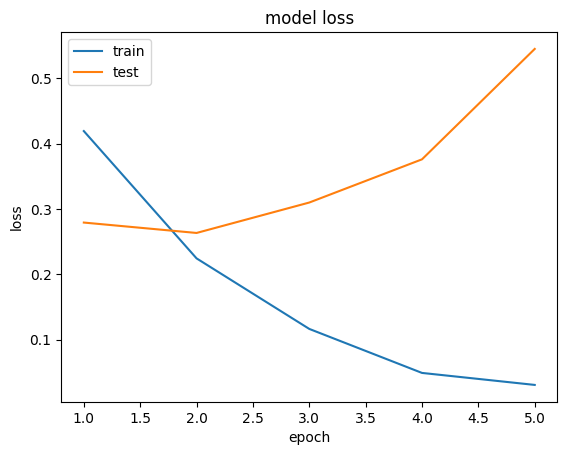

In [14]:
# 학습 과정 시각화를 위한 라이브러리
import matplotlib.pyplot as plt

# 학습 횟수(epoch)의 범위를 1부터 총 학습 횟수까지 설정
epochs = range(1, len(history.history['acc']) + 1)

# 학습 데이터의 손실값(loss) 변화 그래프
plt.plot(epochs, history.history['loss'])

# 검증 데이터의 손실값(val_loss) 변화 그래프
plt.plot(epochs, history.history['val_loss'])

# 그래프 제목과 축 이름 설정
plt.title('model loss')       # 그래프 제목
plt.ylabel('loss')            # y축 이름: 손실값
plt.xlabel('epoch')           # x축 이름: 학습 반복 횟수(epoch)

# 범례(legend) 추가 → train(학습 데이터) vs test(검증 데이터)
plt.legend(['train', 'test'], loc='upper left')

# 그래프 출력
plt.show()